In [1414]:
SCOPETYPE     = 'OPENADC'
PLATFORM      = 'CW308_STM32F3'
CRYPTO_TARGET = 'TINYAES128C'
SS_VER        = 'SS_VER_1_1'

In [1415]:
%%sh -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd ../../../hardware/victims/firmware/simpleserial-snowv-lfsr
make -s PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3

Building for platform CW308_STM32F3 with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
Building for platform CW308_STM32F3 with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
Building for platform CW308_STM32F3 with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (GNU Arm Embedded Toolchain 10-2020-q4-major) 10.2.1 20201103 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

.
Compiling:
    simpleserial-snowv-lfsr.c ...Done!
.
Compiling:
    .././simpleserial/simpleserial.c ...Done!
.
Compiling:
    .././hal/stm32f3/stm32f3_hal.c ...Done!
.
Co

In [1416]:
%run "../../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍


In [1417]:
# If you need to program - run this
fw_path = '../../../hardware/victims/firmware/simpleserial-snowv-lfsr/simpleserial-snowv-lfsr-{}.hex'.format(PLATFORM)
cw.program_target(scope, prog, fw_path)

Detected unknown STM32F ID: 0x446
Extended erase (0x44), this can take ten seconds or more
Attempting to program 6371 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 6371 bytes


In [1418]:
from __future__ import division, print_function
import time
import os
import random
from datetime import datetime
from serial import Serial, PARITY_ODD
import chipwhisperer as cw
from tqdm.notebook import trange
import numpy as np
import scipy
import scipy.stats
import scipy.io
import math
import matplotlib.pyplot as plt
import holoviews as hv

In [1419]:
project = cw.create_project("projects/snowv_lfsr_update_sw_cw308.cwp", overwrite = True)

In [1420]:
# Set list of IVs
iv = []
for k in range(1000):
    sub_iv = []
    
    for l in range(16):
        sub_iv.append(random.randint(0, 255))

    iv.append(sub_iv)
"""iv= []
for j in range(1000):
    sub_iv = []
    for k in range(16):
        sub_iv.append(0)
    iv.append(sub_iv)"""

iv = np.array(iv)
print(np.shape(iv))

(1000, 16)


In [1421]:
print(iv)

[[225 132 199 ... 184  31  69]
 [ 58 182 157 ... 190 135 156]
 [146 134 139 ... 139  16 247]
 ...
 [ 37 135  85 ...  10 163  70]
 [244  64  67 ... 143 128  49]
 [ 47 186 153 ...  19  99  69]]


In [1422]:
# CW Functions to send and recieve data and capture traces

def send_data_chunk(target, command, data_in):
    target.simpleserial_write(command, data_in)
    time.sleep(0.1)
    return None

def get_data_chunk(target, command):
    target.simpleserial_write(command, bytearray(0))
    time.sleep(0.1) 
    data_out = target.simpleserial_read('r', CHUNK_SIZE)
    return data_out

def capture_trace(scope,target):
    target.reinit()
    time.sleep(0.05)
    scope.arm()
    time.sleep(0.05)   
    
    target.simpleserial_write('l', bytearray(0))
    
    timeout = 50
    while target.isDone() is False and timeout:
        timeout -= 1
        time.sleep(0.01)
    try:
        ret = scope.capture()
        if ret:
            print('Timeout happened during acquisition')
    except IOError as e:
        print('IOError: %s' % str(e))
    
    time.sleep(0.1) 
    A_captured = get_data_chunk(target, command = 'c')
    time.sleep(0.1) 
    B_captured = get_data_chunk(target, command = 'd')
    time.sleep(0.1) 
    u_captured = get_data_chunk(target, command = 'e')
    #print(u_captured)
    time.sleep(0.01)
    trace = scope.get_last_trace()
    time.sleep(0.05)    
    
    return trace, A_captured, B_captured, u_captured

In [1423]:
# SNOW-V Functions

def MAKEU16(a, b):
    return ((a << 8) | b)

def mul_x(v, c):
    if v & 0x8000:
        return (((v << 1) ^ c) & 0xffff)
    else:
        return ((v << 1) & 0xffff)
        
def mul_x_inv(v, d):
    if v & 0x0001:
        return (((v >> 1) ^ d) & 0xffff)
    else:
        return ((v >> 1) & 0xffff)

In [1424]:
# Set Key

"""key = [0x87, 0x52, 0xef, 0xa0, 0xa1, 0xa2, 0xa3, 0xa4,
       0xa5, 0xa6, 0xa7, 0xa8, 0xa9, 0xaa, 0xb0, 0xb1,
       0xb9, 0xb8, 0xb7, 0xb6, 0xb5, 0xb4, 0xb3, 0xb2,
       0xba, 0xbb, 0xbc, 0xbd, 0xbe, 0xbf, 0xcf, 0xdf]"""

key = [0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff]

"""key= []
for j in range(100):
    sub_key = []
    for k in range(32):
        sub_key.append(255)
    key.append(sub_key)"""
key = np.array(key)
print(np.shape(key))
"""key = [0x50, 0x51, 0x52, 0x53, 0x54, 0x55, 0x56, 0x57, 
       0x58, 0x59, 0x5a, 0x5b, 0x5c, 0x5d, 0x5e, 0x5f,
       0x0a, 0x1a, 0x2a, 0x3a, 0x4a, 0x5a, 0x6a, 0x7a, 
       0x8a, 0x9a, 0xaa, 0xba, 0xca, 0xda, 0xea, 0xfa]"""

(32,)


'key = [0x50, 0x51, 0x52, 0x53, 0x54, 0x55, 0x56, 0x57, \n       0x58, 0x59, 0x5a, 0x5b, 0x5c, 0x5d, 0x5e, 0x5f,\n       0x0a, 0x1a, 0x2a, 0x3a, 0x4a, 0x5a, 0x6a, 0x7a, \n       0x8a, 0x9a, 0xaa, 0xba, 0xca, 0xda, 0xea, 0xfa]'

In [1425]:
print(key)

[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255]


In [1426]:
# Set parameters

NUM_TRACES         = 1000
CHUNK_SIZE         = 32
scope.adc.samples  = 20000 
acquisition_number = 1

In [1427]:
# Set the B registers

B = [0] * 16
for j in range(NUM_TRACES):
    for i in range(8):
        B[i]     = 0x0000
        B[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16])
        
B = np.array(B)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

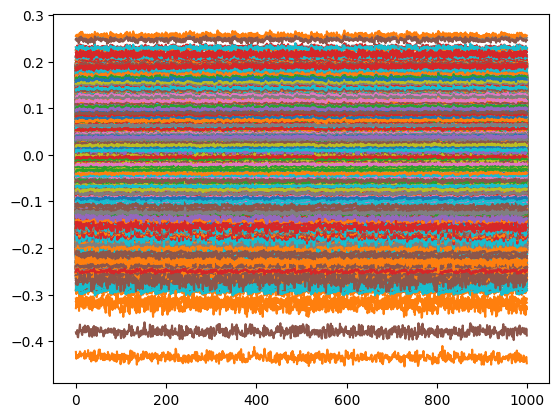

In [1428]:
traces_array     = []
A_captured_array = []
B_captured_array = []
u_captured_array = []


for j in trange(NUM_TRACES, desc='Capturing traces'):
    A = [0] * 16
    for i in range(8):
        A[i]     = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
    A = np.array(A)

    u_expected = mul_x(A[0], 0x990f) ^ A[1] ^ mul_x_inv(A[8], 0xcc87) ^ B[0]
    
    _          = send_data_chunk(target, command = 'a', data_in = bytearray(A.astype('int16')))
    _          = send_data_chunk(target, command = 'b', data_in = bytearray(B.astype('int16')))
    #_          = send_data_chunk(target, command = 'k', data_in = bytearray(key.astype('int16')))
    #_          = send_data_chunk(target, command = 'i', data_in = bytearray(iv[j].astype('int16')))
    trace, A_captured, B_captured, u_captured_arr = capture_trace(scope,target)
    
    u_captured = MAKEU16(u_captured_arr[1], u_captured_arr[0])
    
    """# check if the sent data are captured correctly, and the received data is the expected result of computation
    assert u_expected == u_captured
    assert bytearray(A.astype('int16')) == A_captured
    assert bytearray(B.astype('int16')) == B_captured"""
                                      
    A_captured_array.append(A_captured)
    B_captured_array.append(B_captured)
    u_captured_array.append(u_captured)
    traces_array.append(trace)

filename = 'snowv_acq_'+str(acquisition_number)+'.mat'
mdic     = {'traces_array': np.array(traces_array), 'A_captured_array': np.array(A_captured_array), 'B_captured_array': np.array(B_captured_array)}
scipy.io.savemat('./'+filename, mdic)
plt.plot(traces_array)
plt.show()

In [1429]:
print(np.shape(traces_array))

(1000, 20000)


In [1430]:
print(u_captured_array)

[34674, 28574, 14296, 62824, 44217, 9678, 30945, 38320, 25238, 45448, 41373, 53956, 8503, 39904, 27597, 62170, 11786, 331, 50721, 7914, 41193, 63310, 14011, 34344, 16303, 35919, 34706, 27377, 12303, 33028, 41984, 24066, 62800, 43583, 52509, 16138, 57776, 18532, 22726, 35610, 22356, 36306, 30930, 21180, 36531, 41507, 37148, 6863, 34354, 55461, 2740, 58775, 56333, 65269, 43282, 46079, 7129, 25760, 1171, 41501, 13170, 50120, 38771, 45481, 796, 16321, 39812, 52057, 21257, 1627, 38529, 1287, 791, 48720, 11633, 1156, 45425, 10116, 28432, 58962, 41076, 29634, 21478, 8920, 17364, 25318, 15358, 10327, 23244, 24134, 19216, 45538, 30169, 18596, 56704, 7490, 39732, 37560, 3846, 22598, 2452, 58382, 23217, 28091, 65376, 5135, 33297, 23150, 10283, 15377, 34982, 19268, 29981, 48188, 5876, 54174, 62815, 35225, 61987, 22547, 12909, 19712, 57256, 5745, 50075, 31690, 384, 20330, 44506, 17364, 22098, 60074, 60364, 25923, 41432, 26202, 42814, 37940, 14916, 38419, 46201, 46772, 8456, 18557, 63242, 14089, 959

In [1431]:
import time
import matplotlib.pylab as plt
from datetime import datetime
now = datetime.now()
fmt_string = '{:02}{:02}_{}.npy'
trace_array_file_path = fmt_string.format(now.hour, now.minute, "rand_traces_full_algo_new220k")
iv_array_file_path = fmt_string.format(now.hour, now.minute, "rand_iv_full_algo_new220k")
np.save(trace_array_file_path, traces_array)
np.save(iv_array_file_path, iv)

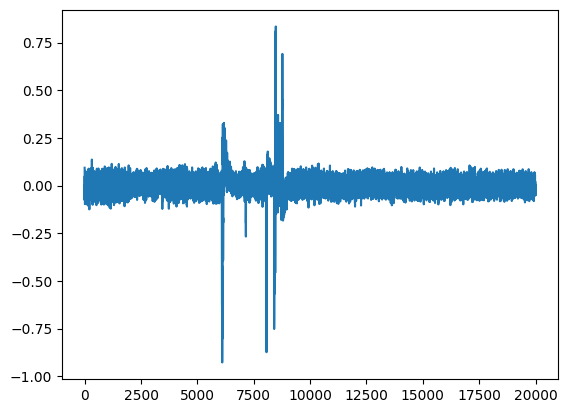

In [1432]:
# Known Intermediate Correlation: Correlation with u

HW = [(bin(n)).count("1") for n in range(0, 131072)]

samples_per_trace = np.shape(traces_array)[1]
num_traces        = np.shape(traces_array)[0]

HW_u = []
for u in u_captured_array:
    HW_u.append(HW[u])

plt.figure()
hyp_pwr        = np.array(HW_u).reshape(-1,1)
traces_hyp_pwr = np.concatenate((traces_array,hyp_pwr), axis = 1)

correlation    = np.corrcoef(traces_hyp_pwr.T)
corr           = correlation[samples_per_trace, :samples_per_trace]

plt.plot(corr)
plt.show()

In [1239]:
u_hyp = []
HW_u_hyp = []
for j in range(100):
    sub_u_hyp = []
    for A[8] in range(0, 256):
        for i in range(8):
            A[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            #B[i] = 0x0000
        sub_u_hyp.append(mul_x(A[0], 0x990f) ^ A[1] ^ mul_x_inv(A[8], 0xcc87) ^ B[0])    
    u_hyp.append(sub_u_hyp)
print("size of u_hyp",np.shape(u_hyp))

for m in range(len(u_hyp)):
    sub_HW_u_hyp = []
    for s in range(256):
        sub_HW_u_hyp.append(('{0:08b}'.format(u_hyp[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp.append(sub_HW_u_hyp)
print("size of HW_u_hyp", np.shape(HW_u_hyp))

size of u_hyp (100, 256)
size of HW_u_hyp (100, 256)


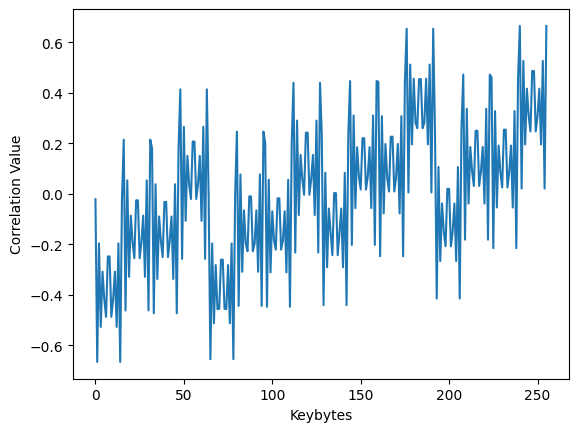

In [1240]:
samples_per_trace = np.shape(HW_u_hyp)[1]
num_traces = np.shape(HW_u_hyp)[0]

plt.figure()
hyp_pwr = np.array(HW_u).reshape(-1,1)

traces_hyp_pwr = np.concatenate((HW_u_hyp,hyp_pwr), axis = 1)
    
correlation = np.corrcoef(traces_hyp_pwr.T)
corr = correlation[samples_per_trace, :samples_per_trace]
plt.plot(corr)
plt.xlabel('Keybytes')
plt.ylabel('Correlation Value')
#plt.savefig('snowv_cpa.tif')
plt.show()

In [454]:
B = np.zeros(2, int)
for i in range(2):
    idx = np.argmax(corr)
    B[i]=idx; corr[idx]=0 
print(B)   

'B = np.zeros(2, int)\nfor i in range(2):\n    idx = np.argmax(corr)\n    B[i]=idx; corr[idx]=0 \nprint(B)  '

In [455]:
B = np.zeros(2, int)
for i in range(2):
    idx = np.argmin(corr)
    B[i]=idx; corr[idx]=0 
print(B)

'B = np.zeros(2, int)\nfor i in range(2):\n    idx = np.argmin(corr)\n    B[i]=idx; corr[idx]=0 \nprint(B) '